# TP - Réduction de dimensionnalité

Ce notebook est une version TP sans code solution. La première partie de chargement / exploration des données est conservée pour permettre de démarrer l'exercice. Les autres parties contiennent uniquement les travaux demandés.

## 0. Data export / chargement des données à conserver

Dataset : Loan eligibility  
Source indiquée dans le notebook original : IBM / Predict-loan-eligibility-using-IBM-Watson-Studio.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [34]:
!wget https://raw.githubusercontent.com/profsarang/ThinkingDataScience/main/data/train.csv

--2026-06-24 19:22:08--  https://raw.githubusercontent.com/profsarang/ThinkingDataScience/main/data/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37397 (37K) [text/plain]
Saving to: ‘train.csv.1’

train.csv.1         100%[===================>]  36.52K  --.-KB/s    in 0.004s  

2026-06-24 19:22:08 (9.35 MB/s) - ‘train.csv.1’ saved [37397/37397]



In [35]:
df = pd.read_csv("train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## 1. Valeurs manquantes et imputation

### Travail demandé
- Calculer le nombre de valeurs manquantes par colonne.
- Calculer la proportion de valeurs manquantes par colonne.
- Identifier les colonnes qui dépassent un seuil de 3 % de valeurs manquantes.
- Proposer une stratégie de traitement : suppression, médiane, mode ou autre méthode.
- Justifier le choix de la méthode d’imputation pour LoanAmount, Loan_Amount_Term et Credit_History.

Text(0, 0.5, 'Frequency')

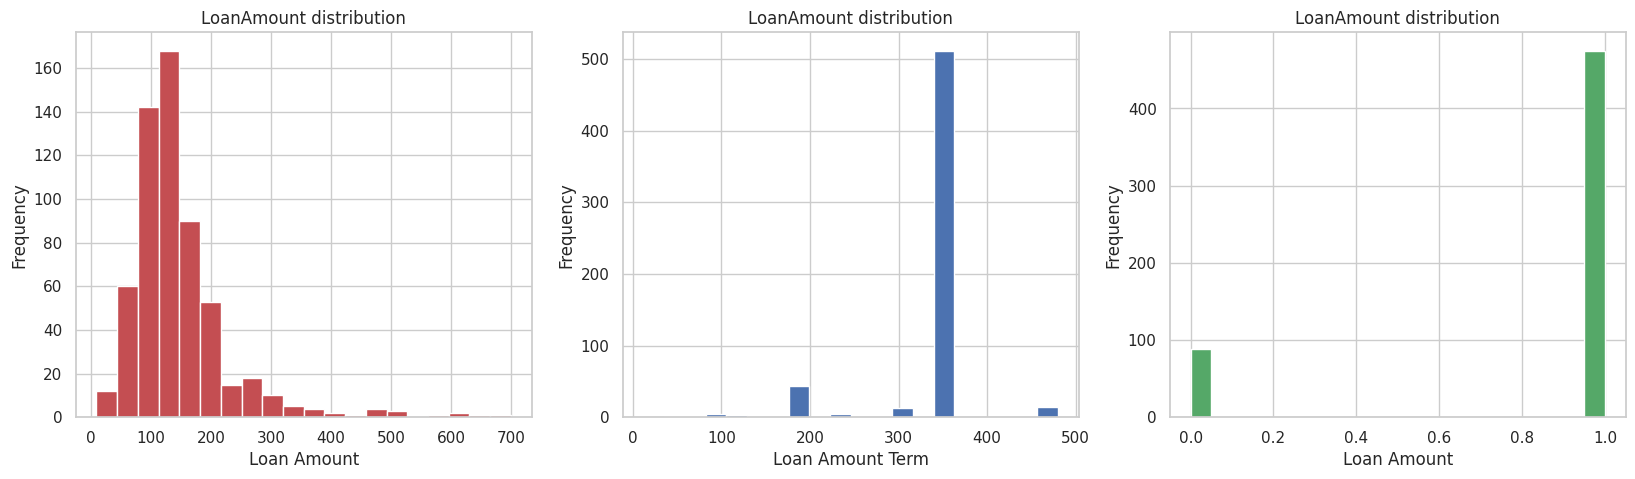

In [37]:
sns.set(style='whitegrid')
f, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(20,5))

df['LoanAmount'].hist(bins=20,color='r',ax=ax1)
ax1.set_title('LoanAmount distribution')
ax1.set_xlabel('Loan Amount')
ax1.set_ylabel("Frequency")

df['Loan_Amount_Term'].hist(bins=20,color='b',ax=ax2)
ax2.set_title('LoanAmount distribution')
ax2.set_xlabel('Loan Amount Term')
ax2.set_ylabel("Frequency")

df['Credit_History'].hist(bins=20,color='g',ax=ax3)
ax3.set_title('LoanAmount distribution')
ax3.set_xlabel('Loan Amount')
ax3.set_ylabel("Frequency")

In [38]:
a = df.isnull().sum()/len(df)
variables = df.columns[:-1]
variable = []
for i in range(0,len(df.columns[:-1])):
  if a[i]>0.03:
    variable.append(variables[i])
print(variable)


['Self_Employed', 'LoanAmount', 'Credit_History']


/tmp/ipykernel_4883/314678834.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if a[i]>0.03:


## 2. Encodage des variables catégorielles

### Travail demandé
- Identifier les variables catégorielles du dataset.
- Encoder les variables catégorielles avec une méthode adaptée.
- Vérifier que toutes les variables utilisées par les modèles sont numériques.
- Expliquer en une phrase la limite de LabelEncoder pour certaines variables catégorielles.

In [39]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_4883/168855424.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_4883/168855424.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## 3. Vérification de la variance

### Travail demandé
- Calculer la variance des variables explicatives numériques.
- Choisir un seuil de variance et l’appliquer au dataset.
- Lister les variables conservées et les variables écartées.
- Interpréter pourquoi une faible variance peut réduire l’intérêt prédictif d’une variable.

In [40]:
label_encoder = LabelEncoder()
columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for i in columns:
    df[i] = label_encoder.fit_transform(df[i])

In [41]:
df.var(numeric_only=True)

,0
Gender,1.778751e-01
Married,2.351972e-01
Dependents,1.255589e+00
Education,1.708902e-01
Self_Employed,2.859435e-01
ApplicantIncome,3.732039e+07
CoapplicantIncome,8.562930e+06
LoanAmount,7.074027e+03
Loan_Amount_Term,4.151048e+03
Credit_History,1.241425e-01


In [43]:
# Sélection des colonnes numériques en omettant 'Loan_ID' et 'Loan_Status'
numeric = df[df.columns[1:-1]]
var = numeric.var()
numeric_cols = numeric.columns
variable = []

# Seuil de variance fixé à 10
for i in range(0, len(numeric_cols)):
    if var[i] >=10: # variance threshold
        variable.append(numeric_cols[i])

variable

/tmp/ipykernel_4883/1561975309.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if var[i] >=10: # variance threshold


['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

## 4. Corrélation entre variables

### Travail demandé
- Calculer la matrice de corrélation entre les variables explicatives.
- Tracer une représentation graphique de la matrice de corrélation.
- Identifier les paires de variables dont la corrélation absolue dépasse 0,5.
- Discuter si une des deux variables d’une paire fortement corrélée peut être supprimée.

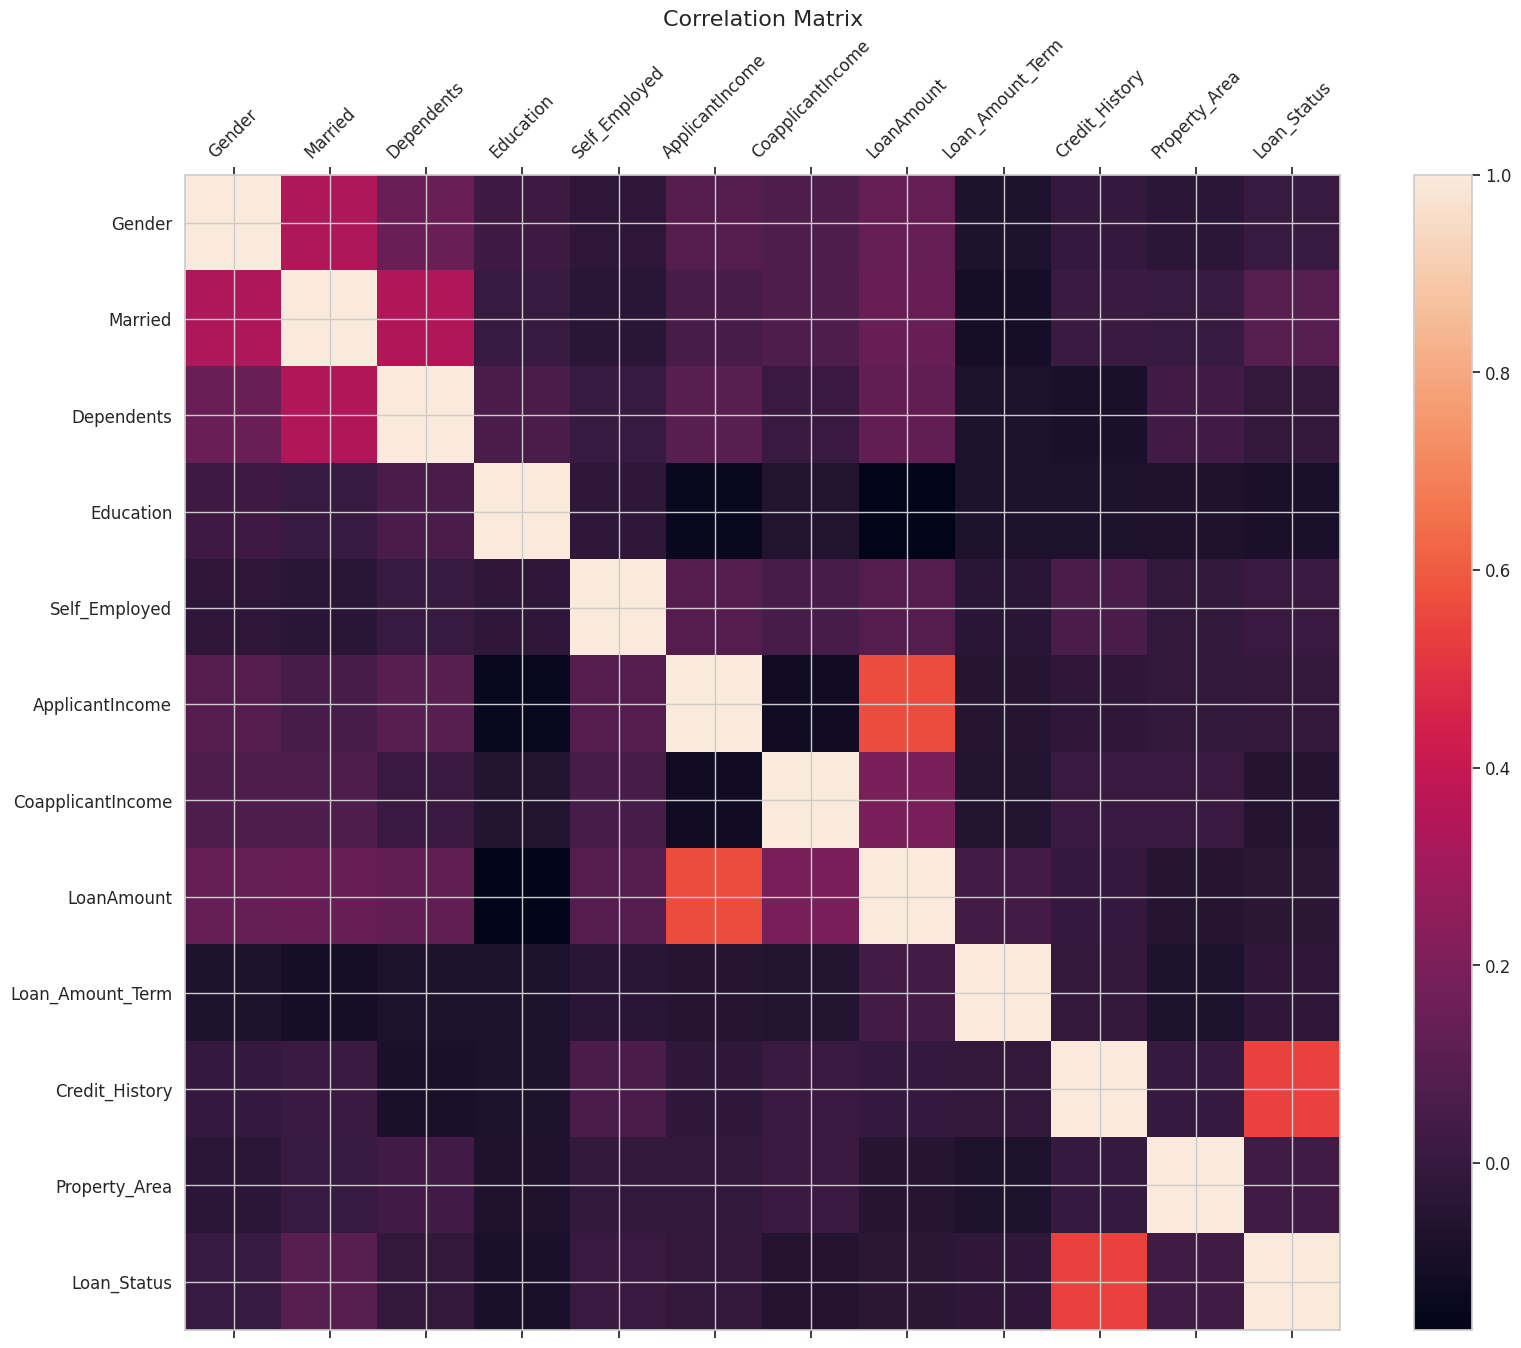

In [51]:
# 1. garder uniquement les colonnes numériques
df_num = df.select_dtypes(include=['number'])

# 2. matrice de corrélation
corr = df_num.corr()

# 3. plot
f = plt.figure(figsize=(19, 15))
ax = f.add_subplot(111) # Obtenir un objet Axes
im = ax.matshow(corr.values) # Utiliser ax.matshow au lieu de plt.matshow

plt.xticks(range(len(corr.columns)), corr.columns, fontsize=12, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=12)

cb = f.colorbar(im, ax=ax) # Lier la barre de couleur à l'image et aux axes
cb.ax.tick_params(labelsize=12)

plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [54]:
f = plt.figure(figsize=(10, 8))
plt.matshow(df.iloc[:, :].corr(), fignum=f.number)
plt.xticks(range(df.iloc[:, :].select_dtypes(['number']).shape[1]), df.iloc[:, :].select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.iloc[:, :].select_dtypes(['number']).shape[1]), df.iloc[:,:].select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)

ValueError: could not convert string to float: 'LP001002'

<Figure size 1000x800 with 0 Axes>

## 5. Sélection par Random Forest

### Travail demandé
- Entraîner un modèle Random Forest pour estimer l’importance des variables.
- Classer les variables selon leur importance relative.
- Tracer un graphique horizontal des importances.
- Sélectionner les variables les plus importantes et justifier votre choix.

In [55]:
from sklearn.ensemble import RandomForestRegressor

# Suppression de la colonne d'identifiant
df = df.drop(['Loan_ID'], axis=1)

# Initialisation du modèle
model = RandomForestRegressor(random_state=1, max_depth=10)

# Définition de la cible (y) et des variables explicatives (X)
y = df['Loan_Status']
X = df.drop(['Loan_Status'], axis=1)

# Entraînement du modèle
model.fit(X, y)

# Affichage des paramètres du modèle
RandomForestRegressor(max_depth=10, random_state=1)


RandomForestRegressor(max_depth=10, random_state=1)

In [57]:
!wget https://github.com/IBM/Predict-loan-eligibility-using-IBM-Watson-Studio/blob/main/Dataset/test_lAUu6dG.csv

--2026-06-24 20:00:39--  https://github.com/IBM/Predict-loan-eligibility-using-IBM-Watson-Studio/blob/main/Dataset/test_lAUu6dG.csv
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘test_lAUu6dG.csv’

test_lAUu6dG.csv        [ <=>                ] 399.22K  --.-KB/s    in 0.1s    

2026-06-24 20:00:40 (3.09 MB/s) - ‘test_lAUu6dG.csv’ saved [408801]



## 6. Backward feature elimination avec RFE

### Travail demandé
- Appliquer RFE avec un estimateur de régression logistique.
- Sélectionner les 4 variables les plus informatives.
- Afficher le support des variables sélectionnées et leur ranking.
- Comparer les variables retenues par RFE avec celles retenues par Random Forest.

## 7. Forward feature selection avec SelectKBest

### Travail demandé
- Appliquer SelectKBest avec f_classif.
- Sélectionner les 7 meilleures variables.
- Tracer le score de chaque variable.
- Comparer les résultats avec RFE et Random Forest.

## 8. Analyse factorielle

### Travail demandé
- Installer ou importer la librairie nécessaire si elle est disponible dans votre environnement.
- Appliquer une analyse factorielle au dataset préparé.
- Tracer le scree plot des valeurs propres.
- Déterminer le nombre de facteurs à retenir et justifier la décision.

## 9. PCA et Kernel PCA

### Travail demandé
- Appliquer PCA avec 2 composantes sur les variables explicatives.
- Appliquer Kernel PCA avec noyau RBF et 2 composantes.
- Tracer les projections 2D en colorant les points par Loan_Status.
- Comparer la séparation visuelle obtenue par PCA et Kernel PCA.

## 10. Independent Component Analysis - ICA

### Travail demandé
- Appliquer FastICA avec 2 composantes.
- Tracer la projection des observations dans le plan des deux composantes.
- Interpréter la différence entre composantes indépendantes et composantes principales.

## 11. Isomap

### Travail demandé
- Appliquer Isomap avec 5 voisins et 2 composantes.
- Tracer la projection 2D obtenue.
- Expliquer l’effet possible du paramètre n_neighbors sur le résultat.

## 12. t-SNE

### Travail demandé
- Standardiser les variables explicatives.
- Appliquer PCA puis t-SNE dans un pipeline.
- Tracer la projection t-SNE en deux dimensions.
- Commenter la séparation des groupes et les précautions d’interprétation.

## 13. UMAP

### Travail demandé
- Appliquer UMAP avec n_neighbors=5, min_dist=0,3 et metric="correlation".
- Tracer la projection UMAP.
- Comparer UMAP avec t-SNE en termes de lisibilité et de stabilité.
- Indiquer les paramètres qu’il faudrait tester pour améliorer la projection.

## 14. SVD et validation croisée

### Travail demandé
- Préparer la matrice X et la cible y pour SVD.
- Construire plusieurs pipelines TruncatedSVD + LogisticRegression avec un nombre de composantes de 1 à 10.
- Évaluer chaque pipeline par validation croisée.
- Tracer la performance selon le nombre de composantes.
- Choisir un nombre de composantes en tenant compte de l’accuracy et de la dispersion.

## 15. LDA sur le dataset digits

### Travail demandé
- Charger le dataset digits depuis scikit-learn.
- Séparer les données en train et test avec stratification.
- Appliquer LDA pour différents nombres de composantes.
- Entraîner un classifieur sur les données transformées.
- Comparer l’accuracy du modèle complet avec celle du modèle réduit.
- Conclure sur le compromis entre réduction de dimension et performance.

## 16. Conclusion générale

### Travail demandé
- Présenter un tableau comparatif des méthodes testées.
- Indiquer la méthode la plus adaptée pour la visualisation.
- Indiquer la méthode la plus adaptée pour la sélection de variables.
- Indiquer la méthode la plus adaptée pour la classification supervisée.
- Formuler deux limites méthodologiques du notebook et deux améliorations possibles.